# Focus on processing the HPPC data
2025/04/30

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

/Users/ampere/code/formation-modeling/src/cellsim.py:563: SyntaxWarning: invalid escape sequence '\e'
  axs[i].plot(xx, self.ocv_p + self.eta_p, ls='-', c='b', label='$U^+ + \eta^+$')
/Users/ampere/code/formation-modeling/src/cellsim.py:569: SyntaxWarning: invalid escape sequence '\e'
  axs[i].plot(xx, self.ocv_n - self.eta_n, ls='-', c='r', label='$U^- - \eta^-$')
/Users/ampere/code/formation-modeling/src/cellsim.py:571: SyntaxWarning: invalid escape sequence '\m'
  axs[i].axhline(y=self.cell.U_SEI2, ls='--', c='m', label='$U_{\mathrm{VC}}$ = 1.35V')
/Users/ampere/code/formation-modeling/src/cellsim.py:572: SyntaxWarning: invalid escape sequence '\m'
  axs[i].axhline(y=self.cell.U_SEI1, ls='--', c='c', label='$U_{\mathrm{EC}}$ = 0.80V')
/Users/ampere/code/formation-modeling/src/cellsim.py:611: SyntaxWarning: invalid escape sequence '\m'
  axs[i].plot(xx, self.q_sei2, c='m', label='$Q_{\mathrm{VC}}$')
/Users/ampere/code/formation-modeling/src/cellsim.py:612: SyntaxWarning: invalid esca

# Load the experimental data

In [2]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

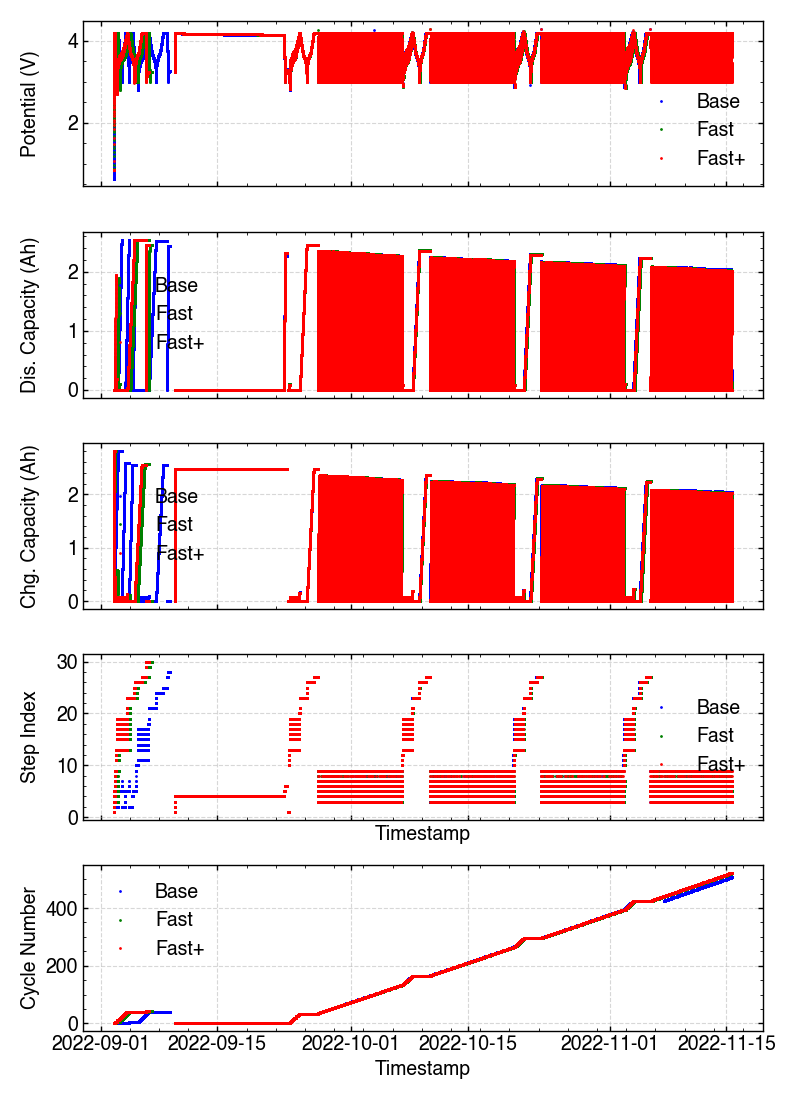

In [3]:
%matplotlib widget

fig, axs = plt.subplots(5, 1, figsize=(8, 11), sharex=True)

xvar = 'Timestamp'
xval1 = df1[xvar]
xval3 = df3[xvar]
xval4 = df4[xvar]

# First subplot
axs[0].plot(xval1, df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(xval3, df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(xval4, df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(xval1, df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(xval3, df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(xval4, df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(xval1, df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(xval3, df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(xval4, df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(xval1, df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(xval3, df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(xval4, df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Fifth suplot (Cycle Number)
axs[4].plot(xval1, df1['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[4].plot(xval3, df3['Cycle Number'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[4].plot(xval4, df4['Cycle Number'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[4].legend()
axs[4].set_ylabel('Cycle Number')
axs[4].set_xlabel(xvar)
axs[4].grid(True, linestyle='--', alpha=0.5)

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

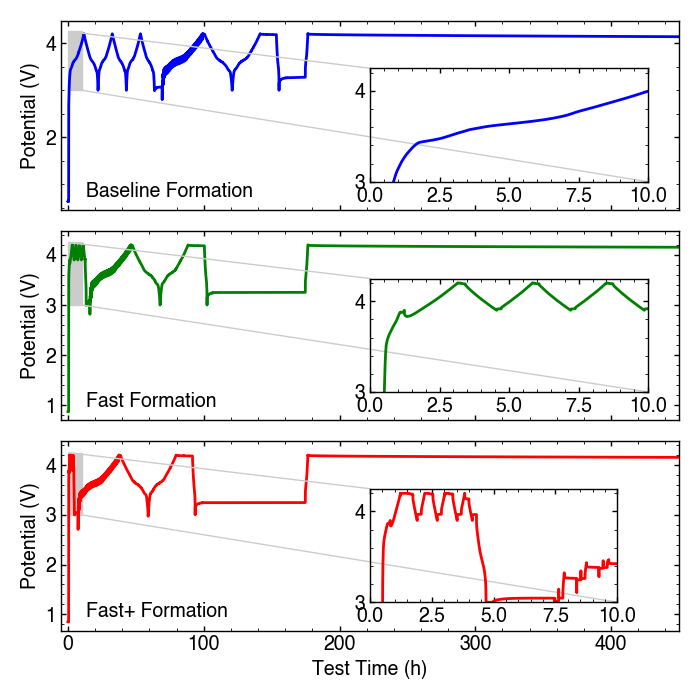

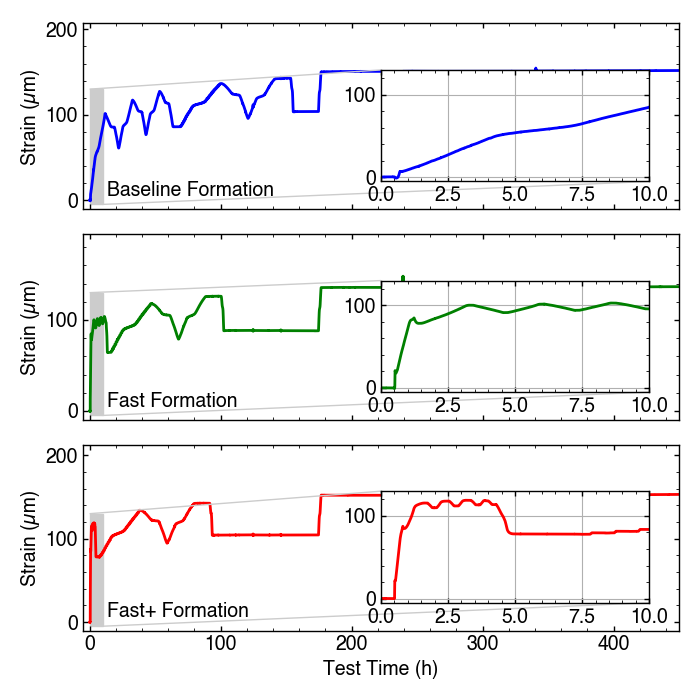

In [4]:
FIGSIZE = (7, 7)
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline Formation', color='blue', ls='-')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast Formation', color='green', ls='-')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+ Formation', color='red', ls='-')
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.4, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='blue')
axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='green')
axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(3, 4.25)
    axins.grid(False)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_voltage.svg', format='svg', dpi=300)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline formation', color='blue', ls='-', marker='', markersize=1)
axs[0].set_ylabel('Strain (µm)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast Formation', color='green', ls='-', marker='', markersize=1)
axs[1].set_ylabel('Strain (µm)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+ Formation', color='red', ls='-', marker='', markersize=1)
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='blue')
axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='green')
axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(-5, 130)
    axins.grid(True)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_strain.svg', format='svg', dpi=300)
plt.show()

In [5]:
# Define the step indices for the HPPC sequence
si1_hppc = [11, 12, 13, 14, 15, 16, 17]
si2_hppc = [13, 14, 15, 16, 17, 18, 19]
si3_hppc = [13, 14, 15, 16, 17, 18, 19]

si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]

In [6]:
def calculate_resistance_estimates(Vmeas, Imeas, time):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    dt = time[0:-2] - time[1:-1]
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where((den < -1.5) & (np.abs(dt) < 10))[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

## First HPPC

In [33]:
# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[df1['Timestamp'] < pd.to_datetime('2022-09-15')]
df3_one = df3[df3['Timestamp'] < pd.to_datetime('2022-09-15')]
df4_one = df4[df4['Timestamp'] < pd.to_datetime('2022-09-15')]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_51799/3483031655.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_51799/3483031655.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

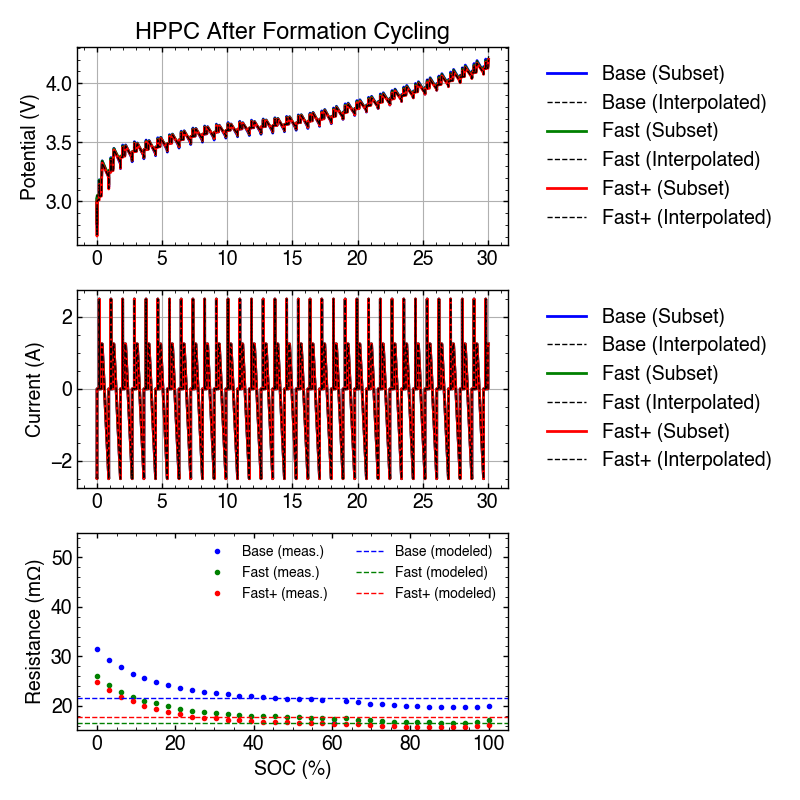

In [34]:
Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

axs[0].set_title('HPPC After Formation Cycling')
axs[0].plot(subset_df1['Time (s)']/3600, subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1/3600, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)']/3600, subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3/3600, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)']/3600, subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4/3600, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)']/3600, subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1/3600, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)']/3600, subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3/3600, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)']/3600, subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4/3600, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]

soc1 = (trs1 - trs1.iloc[0])/np.max(trs1 - trs1.iloc[0])*100
soc3 = (trs3 - trs3.iloc[0])/np.max(trs3 - trs3.iloc[0])*100
soc4 = (trs4 - trs4.iloc[0])/np.max(trs4 - trs4.iloc[0])*100

# axs[2].plot((trs1 - trs1.iloc[0])/3600, Rs_estimate1*1e3, label=f'Base, median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', color='blue', marker='o', markersize=3, linestyle='None')
# axs[2].plot((trs3 - trs3.iloc[0])/3600, Rs_estimate3*1e3, label=f'Fast, median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ', color='green', marker='o', markersize=3, linestyle='None')
# axs[2].plot((trs4 - trs4.iloc[0])/3600, Rs_estimate4*1e3, label=f'Fast+, median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ', color='red', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc1, Rs_estimate1*1e3, label=f'Base (meas.)', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc3, Rs_estimate3*1e3, label=f'Fast (meas.)', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc4, Rs_estimate4*1e3, label=f'Fast+ (meas.)', color='red', marker='o', markersize=3, linestyle='None')

# axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='')
# axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='')
# axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='')

axs[2].axhline(21.50, color='blue', linestyle='--', linewidth=1, label='Base (modeled)')
axs[2].axhline(16.59, color='green', linestyle='--', linewidth=1, label='Fast (modeled)')
axs[2].axhline(17.70, color='red', linestyle='--', linewidth=1, label='Fast+ (modeled)')
# axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
#                 xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
#                 xy=(0.15, 0.83), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
#                 xy=(0.15, 0.76), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('SOC (%)')
axs[2].grid(False)
axs[2].set_ylim(15,55)
axs[2].set_ylabel('Resistance (mΩ)')
axs[2].legend(loc='upper right', ncols=2, fontsize=10)
plt.savefig('outputs/figures/hppc_after_cycling.svg', format='svg', dpi=300)
# axs[2].set_xlim((0, 5000))?

## Second HPPC (after formation aging)

In [35]:
si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]

# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[(df1['Timestamp'] > pd.to_datetime('2022-09-15')) & (df1['Timestamp'] < pd.to_datetime('2022-10-01'))]
df3_one = df3[(df3['Timestamp'] > pd.to_datetime('2022-09-15')) & (df3['Timestamp'] < pd.to_datetime('2022-10-01'))]
df4_one = df4[(df4['Timestamp'] > pd.to_datetime('2022-09-15')) & (df4['Timestamp'] < pd.to_datetime('2022-10-01'))]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)

plt.savefig('outputs/figures/hppc_after_cycling.svg', format='svg', dpi=300)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_51799/3519708481.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_51799/3519708481.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

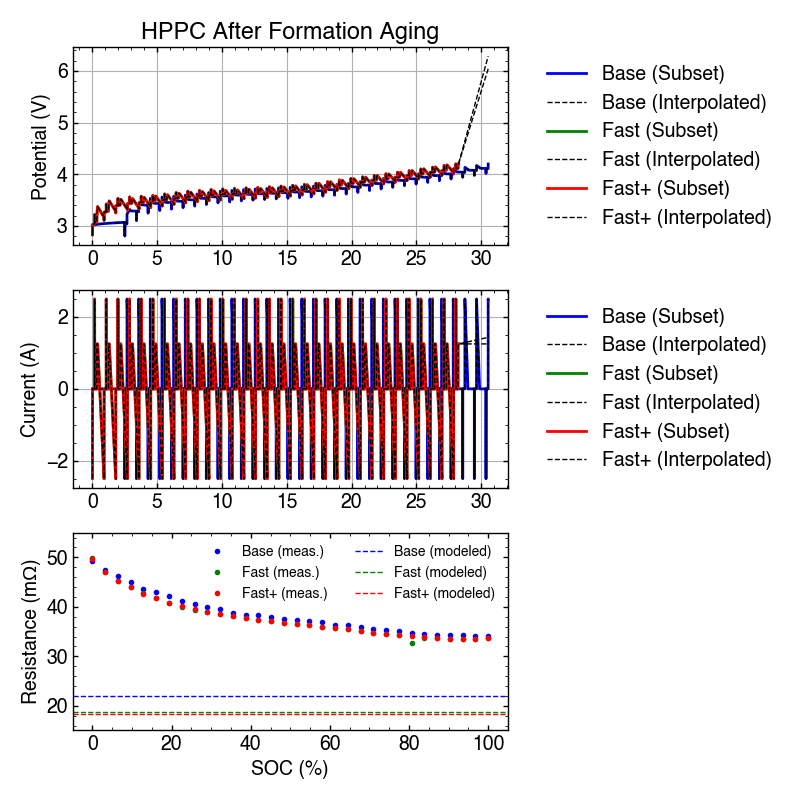

In [36]:
Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

axs[0].set_title('HPPC After Formation Aging')
axs[0].plot(subset_df1['Time (s)']/3600, subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1/3600, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)']/3600, subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3/3600, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)']/3600, subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4/3600, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)']/3600, subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1/3600, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)']/3600, subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3/3600, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)']/3600, subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4/3600, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]

soc1 = (trs1 - trs1.iloc[0])/np.max(trs1 - trs1.iloc[0])*100
soc3 = (trs3 - trs3.iloc[0])/np.max(trs3 - trs3.iloc[0])*100
soc4 = (trs4 - trs4.iloc[0])/np.max(trs4 - trs4.iloc[0])*100

# axs[2].plot((trs1 - trs1.iloc[0])/3600, Rs_estimate1*1e3, label=f'Base, median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', color='blue', marker='o', markersize=3, linestyle='None')
# axs[2].plot((trs3 - trs3.iloc[0])/3600, Rs_estimate3*1e3, label=f'Fast, median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ', color='green', marker='o', markersize=3, linestyle='None')
# axs[2].plot((trs4 - trs4.iloc[0])/3600, Rs_estimate4*1e3, label=f'Fast+, median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ', color='red', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc1, Rs_estimate1*1e3, label=f'Base (meas.)', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc3, Rs_estimate3*1e3, label=f'Fast (meas.)', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(soc4, Rs_estimate4*1e3, label=f'Fast+ (meas.)', color='red', marker='o', markersize=3, linestyle='None')

# axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='')
# axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='')
# axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='')

axs[2].axhline(22.0, color='blue', linestyle='--', linewidth=1, label='Base (modeled)')
axs[2].axhline(18.71, color='green', linestyle='--', linewidth=1, label='Fast (modeled)')
axs[2].axhline(18.31, color='red', linestyle='--', linewidth=1, label='Fast+ (modeled)')
# axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
#                 xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
#                 xy=(0.15, 0.83), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
#                 xy=(0.15, 0.76), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('SOC (%)')
axs[2].grid(False)
axs[2].set_ylim(15,55)
axs[2].set_ylabel('Resistance (mΩ)')
axs[2].legend(loc='upper right', ncols=2, fontsize=10)
# axs[2].set_xlim((0, 5000))?

plt.savefig('outputs/figures/hppc_after_aging.svg', format='svg', dpi=300)

plt.show()